# algoforge — Graph DSL Demo

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent / "src"))

import core.graph as g

## 1. Vertex

In [3]:
a, b, c, d = g.vertices("a", "b", "c", "d")
print(a, b, c, d)
print(a == g.Vertex("a"), a == b)

a b c d
True False


## 2. Walk — 무가중

| 연산자 | 간선 종류 |
|--------|----------|
| `-`    | undirected |
| `>>`   | directed (→) |
| `<<`   | directed (← 반대 방향) |
| `&`    | bidirected (↔) |

In [4]:
walk = a - b - c - d
print(type(walk).__name__)
print("length:", walk.length)
print("vertices:", walk.vertices)
print("is_closed:", walk.is_closed)
print(walk)

Walk
length: 3
vertices: [Vertex(label='a'), Vertex(label='b'), Vertex(label='c'), Vertex(label='d')]
is_closed: False
a - b - c - d


In [5]:
directed = a >> b >> c >> d
print("kind:", directed.kind)
print(directed)

kind: EdgeKind.DIRECTED
a → b → c → d


In [6]:
# 순환 walk
cycle = a - b - c - a
print("is_closed:", cycle.is_closed)

is_closed: True


## 3. WeightedWalk — 가중

In [7]:
ww = a - 3 - b - 2 - c - 5 - d
print(type(ww).__name__)
print("length:", ww.length)
print("weight:", ww.weight)
print("vertices:", ww.vertices)
print(ww)

WeightedWalk
length: 3
weight: 10
vertices: [Vertex(label='a'), Vertex(label='b'), Vertex(label='c'), Vertex(label='d')]
a - 3 - b - 2 - c - 5 - d


In [8]:
# float weights
fw = a - 1.5 - b - 2.5 - c
print("weight:", fw.weight)

weight: 4.0


## 4. Trail / Path 검증

In [9]:
from core.graph.walk import Trail, Path

path = Path([*(a - b - c - d).edges])
print(type(path).__name__, path.length)

# 반복 정점 → 에러
try:
    Path([*(a - b - c - a).edges])
except ValueError as e:
    print(f"Path error: {e}")

Path 3
Path error: Path contains repeated vertex: a


## 5. UnweightedGraph

In [12]:
g1 = g.UnweightedGraph(a - b - c - d)
print(g1)
print("V:", g1.num_vertices, "E:", g1.num_edges)
print("has_edge(a,b):", g1.has_edge(a, b))
print("has_edge(a,c):", g1.has_edge(a, c))
print("neighbors(b):", list(g1.neighbors(b)))
print("degree(b):", g1.degree(b))

UnweightedGraph(-, V=4, E=3)
V: 4 E: 3
has_edge(a,b): True
has_edge(a,c): False
neighbors(b): [Vertex(label='a'), Vertex(label='c')]
degree(b): 2


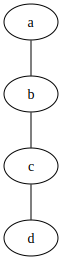

In [13]:
g1

In [ ]:
# directed graph
g_dir = g.UnweightedGraph(a >> b >> c >> d)
print(g_dir)
print("neighbors(a):", list(g_dir.neighbors(a)))
print("neighbors(d):", list(g_dir.neighbors(d)))
g_dir

## 6. WeightedGraph

In [ ]:
g2 = g.WeightedGraph(a - 4 - b - 7 - c - 2 - d)
print(g2)
print("weighted_neighbors(b):", list(g2.weighted_neighbors(b)))

In [ ]:
g2

In [ ]:
# directed weighted
g_dw = g.WeightedGraph(a >> 10 >> b >> 3 >> c)
print("has_edge(a→b):", g_dw.has_edge(a, b))
print("has_edge(b→a):", g_dw.has_edge(b, a))
g_dw

## 7. Graph.infer — 타입 자동 추론

In [ ]:
gi1 = g.Graph.infer(a - b - c)
gi2 = g.Graph.infer(a - 3 - b - 2 - c)
print(type(gi1).__name__, gi1)
print(type(gi2).__name__, gi2)

## 8. contains_path

In [ ]:
graph = g.UnweightedGraph(a - b - c - d)
print(graph.contains_path(a - b - c))      # True
print(graph.contains_path(a - b - c - d))  # True
print(graph.contains_path(a - b - d))      # False (b-d 간선 없음)

## 9. Walk → Graph 변환 (.as_graph)

In [ ]:
sub = (a - b - c).as_graph()
print(sub)
sub

In [ ]:
wsub = (a - 5 - b - 8 - c).as_graph()
print(wsub)
wsub